In [3]:
# from dataloader import PolarisDataReader
# from pipeline import PolarisPipeline
import matplotlib.pyplot as plt
from cil.utilities.display import show1D, show2D, show_geometry
from cil.utilities.jupyter import islicer
import numpy as np
import json
from pathlib import Path
from cil.framework import AcquisitionGeometry, AcquisitionData
from cil.processors import TransmissionAbsorptionConverter, CentreOfRotationCorrector, PaganinProcessor, RingRemover
from cil.plugins.astra import FBP
import os
from glob import glob
from tqdm.notebook import tqdm
import tifffile
from PIL import Image
from PIL.TiffTags import TAGS

import sys
qim3d_repo_root = "/work3/s164564/qim3d"
if qim3d_repo_root not in sys.path:
    sys.path.insert(0, qim3d_repo_root)

if "qim3d" in sys.modules:
    del sys.modules["qim3d"]
import qim3d

In [4]:
class Polaris(object):

    def __init__(self, folder_name=None, roi=None, cor_offset_px=0.0, delta=None, beta=None, energy=None):
        """
        folder_name: Parent folder containing 01-ff and 02-tomo folders.
        roi: Dictionary with keys angle, vertical, horizontal.
        cor_offset_px: Centre-of-rotation offset in detector pixels.
        delta, beta, energy: Optional Paganin parameters.
        """
        default_roi = {'angle': -1, 'vertical': -1, 'horizontal': -1}
        self.folder_name = folder_name
        self._roi = default_roi if roi is None else {**default_roi, **roi}
        self.cor_offset_px = float(cor_offset_px)

        self._files_tomo = None
        self._angles_deg = None
        self._horizontal_shift_px = None
        self._vertical_shift_px = None
        self._roi_slices = None

        self._src_pos = None
        self._det_pos_jitter = None
        self._det_x = None
        self._det_y = None

        self._h_step = 1
        self._v_step = 1

        self._ad = None
        self._arr = None
        self._flats = None
        self._corrected = None

        self._ag = None
        self._ig = None

        self.data = None
        self.sinogram = None
        self.ag = None
        self.ig = None
        self.sino_rings = None
        self.sino_pag = None
        self.reconstructed = None

        self.delta = delta
        self.beta = beta
        self.energy = energy

        if folder_name is not None:
            self.set_up(folder_name=folder_name)

    @staticmethod
    def _get_rot_mat(ang):
        ang_rad = np.deg2rad(ang)
        c = np.cos(ang_rad)
        s = np.sin(ang_rad)
        return np.array([
            [c, -s, 0],
            [s,  c, 0],
            [0,  0, 1]
        ])

    @staticmethod
    def _normalise_axis_slice(axis_slice, axis_length):
        if axis_slice == -1:
            return 0, axis_length, 1

        start = 0 if axis_slice[0] is None else axis_slice[0]
        stop = axis_length if axis_slice[1] is None else axis_slice[1]
        step = 1 if axis_slice[2] is None else axis_slice[2]

        if step <= 0:
            raise ValueError('ROI step must be > 0')

        start = max(0, start)
        stop = min(axis_length, stop)
        if stop <= start:
            print(start, stop, axis_length, axis_slice)
            raise ValueError('ROI has empty range')

        return start, stop, step

    @staticmethod
    def _circular_angle_distance_deg(a, b):
        return np.abs(((a - b + 180.0) % 360.0) - 180.0)

    def _extract_projection_metadata(self, files_tomo):
        rotations = np.empty(len(files_tomo), dtype=np.float64)
        horizontal_shift_px = np.zeros(len(files_tomo), dtype=np.float64)
        vertical_shift_px = np.zeros(len(files_tomo), dtype=np.float64)

        for i, file in enumerate(files_tomo):
            with Image.open(os.path.join(self.projections_path, file)) as img:
                tag_dict = {TAGS[key]: img.tag[key] for key in img.tag_v2}
                image_description = tag_dict.get('ImageDescription', [None])[0]
                if image_description is None:
                    raise ValueError(f"Missing ImageDescription metadata in {file}")

                meta_dict = json.loads(image_description)
                rotations[i] = float(meta_dict['stage_position_mm']['object_rotation']) % 360.0

                pixel_shift = meta_dict.get('pixel_shift_px', {})
                horizontal_shift_px[i] = float(pixel_shift.get('horizontal', 0.0))
                vertical_shift_px[i] = float(pixel_shift.get('vertical', 0.0))

        return rotations, horizontal_shift_px, vertical_shift_px

    def _build_geometry(self, cor_offset_px):
        cor_offset_mm = float(cor_offset_px) * self._panel_pixel_size_x
        corrected_det_pos = self._det_pos_jitter - cor_offset_mm * self._det_x

        return AcquisitionGeometry.create_Cone3D_Flex(
            self._src_pos,
            corrected_det_pos,
            self._det_x,
            self._det_y,
        ).set_panel(
            num_pixels=[self.num_pixels[1], self.num_pixels[0]],
            pixel_size=(self._panel_pixel_size_x, self._panel_pixel_size_y)
        )

    def _to_acquisition_data_with_geometry(self, acquisition_data, geometry, force_float32=False):
        if acquisition_data is None:
            return None

        array = np.asarray(acquisition_data.array)
        if force_float32:
            array = array.astype('float32')

        updated = AcquisitionData(array=array, geometry=geometry)
        if force_float32:
            updated.geometry.dtype = 'float32'
        return updated

    def _sync_geometry_dependent_data(self):
        if self._ag is None:
            return

        self.ag = self._ag
        self.ig = self._ig

        if self._corrected is not None:
            self._ad = AcquisitionData(array=self._corrected, geometry=self._ag)
            self.data = self._ad
        elif self.data is not None:
            self.data = self._to_acquisition_data_with_geometry(self.data, self._ag)

        if self.sinogram is not None:
            self.sinogram = self._to_acquisition_data_with_geometry(self.sinogram, self._ag, force_float32=True)
        if self.sino_rings is not None:
            self.sino_rings = self._to_acquisition_data_with_geometry(self.sino_rings, self._ag, force_float32=True)
        if self.sino_pag is not None:
            self.sino_pag = self._to_acquisition_data_with_geometry(self.sino_pag, self._ag, force_float32=True)

    def _ensure_data_for_pipeline(self):
        if self.data is None:
            if self._ad is not None:
                self.data = self._ad
            elif self._files_tomo is not None:
                self.read()
            else:
                raise RuntimeError('No acquisition data available. Run set_up/read first or provide data.')
        return self.data

    def set_up(self, folder_name=None):
        if folder_name is None:
            folder_name = self.folder_name
        if folder_name is None:
            raise ValueError('folder_name must be provided')

        self.folder_name = folder_name

        with open(os.path.join(folder_name, '02-tomo/scan_information.json'), 'r') as f:
            scan_information = json.load(f)
        with open(os.path.join(folder_name, '02-tomo/Input/command.json'), 'r') as f:
            tomo_command = json.load(f)
        with open(os.path.join(folder_name, '01-ff/Input/command.json'), 'r') as f:
            flat_command = json.load(f)

        self.propagation_distance_mm = scan_information['propagation_distance_mm']
        self.px_size = scan_information['pixel_size_um'] * 1e-3
        source_detector_mm = tomo_command['stage_position_mm']['camera_beam']
        source_object_mm = tomo_command['stage_position_mm']['object_beam']
        roi = tomo_command['camera']['roi_px']
        full_num_pixels = [roi['bot'] - roi['top'] + 1, roi['right'] - roi['left'] + 1]
        num_pixels = full_num_pixels.copy()

        self.total_angle_deg = tomo_command['acquisition']['total_angle_deg']
        self.step_size_deg = tomo_command['acquisition']['step_size_deg']
        self.multirevolution = tomo_command['multirevolution']['enabled']
        self.ring_correction_enabled = tomo_command['ring_correction']['enabled']
        if self.multirevolution:
            self.number_revolutions = tomo_command['multirevolution']['number_revolutions']

        self.roi_flat = roi

        self.projections_path = os.path.join(folder_name, '02-tomo/Output/Binaries')
        self.flats_path = os.path.join(folder_name, '01-ff/Output/Binaries')

        files_tomo = glob('tomo*.tif', root_dir=self.projections_path)
        files_tomo = [file for file in files_tomo if '_' not in file]
        files_tomo.sort()
        files_tomo = np.array(files_tomo)
        
        obj_to_det_mm = source_detector_mm - source_object_mm
        magnification = np.abs((obj_to_det_mm + source_object_mm) / source_object_mm)
        print(f"Estimated magnification: {magnification:.3f}")

        rotation_deg, horizontal_shift_px, vertical_shift_px = self._extract_projection_metadata(files_tomo)
        horizontal_shift_px /= magnification
        vertical_shift_px /= -magnification

        if self.multirevolution:
            order = np.argsort(rotation_deg, kind='mergesort')
            files_tomo = files_tomo[order]
            rotation_deg = rotation_deg[order]
            horizontal_shift_px = horizontal_shift_px[order]
            vertical_shift_px = vertical_shift_px[order]

        if self._roi['angle'] != -1:
            slicing = self._roi['angle']
            files_tomo = files_tomo[slicing[0]:slicing[1]:slicing[2]]
            rotation_deg = rotation_deg[slicing[0]:slicing[1]:slicing[2]]
            horizontal_shift_px = horizontal_shift_px[slicing[0]:slicing[1]:slicing[2]]
            vertical_shift_px = vertical_shift_px[slicing[0]:slicing[1]:slicing[2]]

        v_start, v_stop, v_step = self._normalise_axis_slice(self._roi['vertical'], full_num_pixels[0])
        h_start, h_stop, h_step = self._normalise_axis_slice(self._roi['horizontal'], full_num_pixels[1])

        num_pixels[0] = len(range(v_start, v_stop, v_step))
        num_pixels[1] = len(range(h_start, h_stop, h_step))

        self._files_tomo = files_tomo
        self._angles_deg = rotation_deg
        self._horizontal_shift_px = horizontal_shift_px
        self._vertical_shift_px = vertical_shift_px

        self._roi_slices = {
            'vertical': (v_start, v_stop, v_step) if self._roi['vertical'] != -1 else -1,
            'horizontal': (h_start, h_stop, h_step) if self._roi['horizontal'] != -1 else -1,
        }

        self.tiff_roi = {
            'axis_0': self._roi['angle'],
            'axis_1': self._roi_slices['vertical'],
            'axis_2': self._roi_slices['horizontal']
        }

        n_proj = len(self._files_tomo)
        src_pos = np.zeros((n_proj, 3), dtype=np.float64)
        det_pos = np.zeros((n_proj, 3), dtype=np.float64)
        det_x = np.zeros((n_proj, 3), dtype=np.float64)
        det_y = np.zeros((n_proj, 3), dtype=np.float64)

        src_pos_0 = np.array([0.0, -source_object_mm, 0.0], dtype=np.float64)
        det_pos_0 = np.array([0.0, source_detector_mm - source_object_mm, 0.0], dtype=np.float64)
        det_x_0 = np.array([1.0, 0.0, 0.0], dtype=np.float64)
        det_y_0 = np.array([0.0, 0.0, 1.0], dtype=np.float64)

        for i, ang in enumerate(self._angles_deg):
            Rz = self._get_rot_mat(ang)
            src_pos[i] = Rz @ src_pos_0
            det_pos[i] = Rz @ det_pos_0
            det_x[i] = Rz @ det_x_0
            det_y[i] = Rz @ det_y_0

        du = (self._horizontal_shift_px * self.px_size)[:, None]
        dv = (self._vertical_shift_px * self.px_size)[:, None]

        self._src_pos = src_pos
        self._det_x = det_x
        self._det_y = det_y
        self._det_pos_jitter = det_pos - du * det_x - dv * det_y

        self.num_pixels = num_pixels
        self._h_step = h_step
        self._v_step = v_step
        self._panel_pixel_size_x = self.px_size * h_step
        self._panel_pixel_size_y = self.px_size * v_step

        self._ag = self._build_geometry(self.cor_offset_px)

        from cil.framework import ImageGeometry

        voxel_size_x = self._panel_pixel_size_x / magnification
        voxel_size_y = voxel_size_x
        voxel_size_z = self._panel_pixel_size_y / magnification

        voxel_num_x = num_pixels[1]
        voxel_num_y = num_pixels[1]
        voxel_num_z = num_pixels[0]

        full_center_h = 0.5 * (full_num_pixels[1] - 1)
        full_center_v = 0.5 * (full_num_pixels[0] - 1)
        roi_center_h = h_start + 0.5 * (voxel_num_x - 1) * h_step
        roi_center_v = v_start + 0.5 * (voxel_num_z - 1) * v_step

        center_x = (roi_center_h - full_center_h) * self.px_size / magnification
        center_z = (roi_center_v - full_center_v) * self.px_size / magnification

        self._ig = ImageGeometry(
            voxel_num_x,
            voxel_num_y,
            voxel_num_z,
            voxel_size_x,
            voxel_size_y,
            voxel_size_z,
            center_x=center_x,
            center_z=center_z,
        )

        self._ad = None
        self._arr = None
        self._flats = None
        self._corrected = None

        self.sinogram = None
        self.sino_rings = None
        self.sino_pag = None
        self.reconstructed = None

        self._sync_geometry_dependent_data()

    def set_cor_offset_px(self, cor_offset_px):
        if self._det_pos_jitter is None:
            raise RuntimeError('Geometry must be initialised before setting CoR offset')

        self.cor_offset_px = float(cor_offset_px)
        self._ag = self._build_geometry(self.cor_offset_px)
        self._sync_geometry_dependent_data()

    def get_geometry_for_cor_offset(self, cor_offset_px):
        return self._build_geometry(cor_offset_px)

    def get_geometry(self):
        return self._ag

    def get_image_geometry(self):
        return self._ig

    def get_angles_deg(self):
        return np.array(self._angles_deg, copy=True)

    def plot_source_detector_positions(self, include_cor_offset=False, figsize=(7, 7), elev=20, azim=35):
        if self._src_pos is None or self._det_pos_jitter is None:
            raise RuntimeError('Geometry must be initialised before plotting trajectories')

        det_pos = np.array(self._det_pos_jitter, copy=True)
        det_label = 'Detector position (after jitter)'

        if include_cor_offset:
            cor_offset_mm = float(self.cor_offset_px) * self._panel_pixel_size_x
            det_pos = det_pos - cor_offset_mm * self._det_x
            det_label = f'Detector position (jitter + CoR={self.cor_offset_px:.2f} px)'

        import matplotlib.pyplot as plt

        fig = plt.figure(figsize=figsize)
        ax = fig.add_subplot(111, projection='3d')
        ax.plot(self._src_pos[:, 0], self._src_pos[:, 1], self._src_pos[:, 2], label='Source position')
        ax.plot(det_pos[:, 0], det_pos[:, 1], det_pos[:, 2], label=det_label)

        ax.set_xlabel('X [mm]')
        ax.set_ylabel('Y [mm]')
        ax.set_zlabel('Z [mm]')
        ax.set_title('Source and detector trajectories')
        ax.view_init(elev=elev, azim=azim)
        ax.legend()

        plt.tight_layout()
        plt.show()

        return fig, ax

    def estimate_cor_offset_px(self, max_pairs=16, search_window_px=80, vertical_band=9):
        projection_stack = self._arr
        if projection_stack is None:
            if self._corrected is not None:
                projection_stack = self._corrected
            elif self.data is not None:
                projection_stack = np.asarray(self.data.array)
            else:
                self.read()
                projection_stack = self._arr

        angles = np.asarray(self._angles_deg, dtype=np.float64) % 360.0
        if len(angles) < 2:
            self.set_cor_offset_px(0.0)
            return 0.0

        ref_idx = np.where(angles < 180.0)[0]
        if len(ref_idx) == 0:
            ref_idx = np.arange(len(angles))

        n_pairs = min(max_pairs, len(ref_idx))
        sample_idx = ref_idx[np.linspace(0, len(ref_idx) - 1, n_pairs, dtype=int)]

        v_mid = projection_stack.shape[1] // 2
        band_half = max(1, vertical_band // 2)
        v0 = max(0, v_mid - band_half)
        v1 = min(projection_stack.shape[1], v_mid + band_half + 1)

        offsets = []
        for i in sample_idx:
            target = (angles[i] + 180.0) % 360.0
            j = int(np.argmin(self._circular_angle_distance_deg(angles, target)))

            p1 = projection_stack[i, v0:v1, :].mean(axis=0).astype(np.float64)
            p2 = projection_stack[j, v0:v1, :].mean(axis=0).astype(np.float64)[::-1]

            p1 -= p1.mean()
            p2 -= p2.mean()
            n1 = np.linalg.norm(p1)
            n2 = np.linalg.norm(p2)
            if n1 == 0 or n2 == 0:
                continue
            p1 /= n1
            p2 /= n2

            corr = np.correlate(p1, p2, mode='full')
            center = len(p1) - 1
            window = min(search_window_px, center)
            lo = center - window
            hi = center + window + 1
            shift = np.argmax(corr[lo:hi]) + lo - center
            offsets.append(0.5 * shift)

        estimate = 0.0 if len(offsets) == 0 else float(np.median(offsets))
        self.set_cor_offset_px(estimate)
        return estimate

    def read(self):
        if self._files_tomo is None:
            raise RuntimeError('set_up must be called before read')

        files_tomo = self._files_tomo

        vertical_slicing = self._roi_slices['vertical']
        horizontal_slicing = self._roi_slices['horizontal']

        self._arr = np.empty((len(files_tomo), *self.num_pixels), dtype=np.float32)
        for i, file in enumerate(tqdm(files_tomo, desc='Importing Projections', unit='images')):
            img = tifffile.imread(os.path.join(self.projections_path, file))
            if vertical_slicing != -1 and horizontal_slicing != -1:
                img = img[
                    vertical_slicing[0]:vertical_slicing[1]:vertical_slicing[2],
                    horizontal_slicing[0]:horizontal_slicing[1]:horizontal_slicing[2]
                ]
            elif vertical_slicing != -1:
                img = img[vertical_slicing[0]:vertical_slicing[1]:vertical_slicing[2], :]
            elif horizontal_slicing != -1:
                img = img[:, horizontal_slicing[0]:horizontal_slicing[1]:horizontal_slicing[2]]
            self._arr[i] = img

        files_flat = glob('ff*.tif', root_dir=self.flats_path)
        files_flat.sort()
        self._flats = np.empty((len(files_flat), *self.num_pixels), dtype=np.float32)
        for i, file in enumerate(tqdm(files_flat, desc='Importing Flat fields', unit='images')):
            img = tifffile.imread(os.path.join(self.flats_path, file))[
                self.roi_flat['top']:self.roi_flat['bot'] + 1,
                self.roi_flat['left']:self.roi_flat['right'] + 1
            ]
            if vertical_slicing != -1 and horizontal_slicing != -1:
                img = img[
                    vertical_slicing[0]:vertical_slicing[1]:vertical_slicing[2],
                    horizontal_slicing[0]:horizontal_slicing[1]:horizontal_slicing[2]
                ]
            elif vertical_slicing != -1:
                img = img[vertical_slicing[0]:vertical_slicing[1]:vertical_slicing[2], :]
            elif horizontal_slicing != -1:
                img = img[:, horizontal_slicing[0]:horizontal_slicing[1]:horizontal_slicing[2]]
            self._flats[i] = img

        self._corrected = (self._arr / np.average(self._flats, axis=0)).astype(np.float32)
        self._ad = AcquisitionData(array=self._corrected, geometry=self._ag)
        self.data = self._ad

        self.sinogram = None
        self.sino_rings = None
        self.sino_pag = None
        self.reconstructed = None

        return self._ad

    def get_sinogram(self):
        data = self._ensure_data_for_pipeline()

        self.ag = data.geometry
        self.sinogram = AcquisitionData(data, geometry=self.ag)

        if self._ig is not None:
            self.ig = self._ig
        if self.ig is None:
            raise RuntimeError('Image geometry must be initialised for flex geometry reconstructions')

        print(self.data.shape)
        self.sinogram = TransmissionAbsorptionConverter()(self.sinogram)
        print('TransmissionAbsorptionConverter done')
        self.sinogram.array = self.sinogram.array.astype('float32')
        self.sinogram.geometry.dtype = 'float32'

        self.sino_rings = None
        self.sino_pag = None
        self.reconstructed = None

        return self.sinogram

    def ring_correction(self):
        if self.sinogram is None:
            self.get_sinogram()

        ring_remove = RingRemover()
        ring_remove.set_input(self.sinogram)
        self.sino_rings = ring_remove.get_output()

        self.sino_rings.array = self.sino_rings.array.astype('float32')
        self.sino_rings.geometry.dtype = 'float32'
        print('ring removal done')
        return self.sino_rings

    def paganin(self):
        if self.delta is None or self.beta is None or self.energy is None:
            raise RuntimeError('delta, beta and energy must be provided for Paganin processing')

        paganin_input = self.sino_rings if self.sino_rings is not None else self.sinogram
        if paganin_input is None:
            self.get_sinogram()
            paganin_input = self.sinogram

        paganin_processor = PaganinProcessor(
            delta=self.delta,
            beta=self.beta,
            energy=self.energy,
            full_retrieval=False,
        )

        try:
            paganin_processor.set_input(paganin_input)
            self.sino_pag = paganin_processor.get_output()
        except NotImplementedError as exc:
            raise RuntimeError(
                'PaganinProcessor is not currently implemented for Cone3D_Flex geometry in CIL. '
                'This limitation is independent of ring correction.'
            ) from exc

        self.sino_pag.array = self.sino_pag.array.astype('float32')
        self.sino_pag.geometry.dtype = 'float32'

        input_name = 'ring-corrected sinogram' if self.sino_rings is not None else 'base sinogram'
        print(f'paganin done (input: {input_name})')
        return self.sino_pag

    def _select_recon_input(self):
        if self.sino_pag is not None:
            return self.sino_pag
        if self.sino_rings is not None:
            return self.sino_rings
        return self.sinogram

    def _run_fbp(self, input_array, acquisition_geometry, image_geometry):
        tmp_input = AcquisitionData(array=np.asarray(input_array, dtype=np.float32), geometry=acquisition_geometry)
        tmp_input.reorder(order='astra')
        fbp = FBP(image_geometry, tmp_input.geometry)
        fbp.set_input(tmp_input)
        return fbp.get_output()

    def reconstruct_with_geometry(self, acquisition_geometry, image_geometry=None):
        return self.reconstruct(acquisition_geometry=acquisition_geometry, image_geometry=image_geometry)

    def reconstruct(self, acquisition_geometry=None, image_geometry=None):
        if self.sinogram is None:
            self.get_sinogram()

        recon_input = self._select_recon_input()
        if recon_input is None:
            raise RuntimeError('No reconstruction input available. Build sinogram first.')

        use_ag = recon_input.geometry if acquisition_geometry is None else acquisition_geometry
        use_ig = self.ig if image_geometry is None else image_geometry
        if use_ig is None:
            raise RuntimeError('Image geometry must be provided for reconstruction')

        self.reconstructed = self._run_fbp(recon_input.array, use_ag, use_ig)
        print('FBP reconstruction done')
        return self.reconstructed

    def plot_jitter_corrected_sinogram(self, direction='vertical', slice_index=None, horizontal_sign=-1.0, vertical_sign=1.0):
        if self.sinogram is None:
            self.get_sinogram()

        if self._horizontal_shift_px is None or self._vertical_shift_px is None:
            raise RuntimeError('Jitter metadata is not available. Run set_up first.')

        sinogram = np.asarray(self.sinogram.array)
        if sinogram.ndim != 3:
            raise RuntimeError('Expected sinogram with shape (projection, vertical, horizontal)')

        if sinogram.shape[0] != len(self._horizontal_shift_px) or sinogram.shape[0] != len(self._vertical_shift_px):
            raise RuntimeError('Shift vectors do not match the number of projections in the sinogram')

        shift_h = np.rint(horizontal_sign * np.asarray(self._horizontal_shift_px)).astype(int)
        shift_v = np.rint(vertical_sign * np.asarray(self._vertical_shift_px)).astype(int)

        pad_v = int(np.max(np.abs(shift_v)))
        pad_h = int(np.max(np.abs(shift_h)))

        n_proj, n_v, n_h = sinogram.shape
        shifted = np.zeros((n_proj, n_v + 2 * pad_v, n_h + 2 * pad_h), dtype=sinogram.dtype)

        for i in range(n_proj):
            v0 = pad_v + shift_v[i]
            h0 = pad_h + shift_h[i]
            shifted[i, v0:v0 + n_v, h0:h0 + n_h] = sinogram[i]

        if direction == 'vertical':
            if slice_index is None:
                slice_index = shifted.shape[1] // 2
            slice_index = int(np.clip(slice_index, 0, shifted.shape[1] - 1))
            show2D(shifted[:, slice_index, :], title=f'direction: vertical, slice: {slice_index}')
        elif direction == 'horizontal':
            if slice_index is None:
                slice_index = shifted.shape[2] // 2
            slice_index = int(np.clip(slice_index, 0, shifted.shape[2] - 1))
            show2D(shifted[:, :, slice_index], title=f'direction: horizontal, slice: {slice_index}')
        else:
            raise ValueError("direction must be 'vertical' or 'horizontal'")

        return shifted

    def make_preview_image_geometry(self, voxel_num_z=1):
        from cil.framework import ImageGeometry

        ig = self.get_image_geometry()
        return ImageGeometry(
            ig.voxel_num_x,
            ig.voxel_num_y,
            voxel_num_z,
            ig.voxel_size_x,
            ig.voxel_size_y,
            ig.voxel_size_z,
            center_x=ig.center_x,
            center_z=ig.center_z,
        )

    def launch_cor_offset_explorer(self, offset_min=-30, offset_max=30, step=1, initial=None, preview_voxel_num_z=1):
        import ipywidgets as widgets
        from IPython.display import display

        if initial is None:
            initial = float(round(self.estimate_cor_offset_px()))

        slider = widgets.FloatSlider(
            value=float(initial),
            min=float(offset_min),
            max=float(offset_max),
            step=float(step),
            description='CoR (px)',
            continuous_update=False,
            readout_format='.1f',
        )
        out = widgets.Output()
        preview_ig = self.make_preview_image_geometry(voxel_num_z=preview_voxel_num_z)

        def _update(change):
            offset_px = float(change['new'])
            with out:
                out.clear_output(wait=True)
                self.set_cor_offset_px(offset_px)
                recon = self.reconstruct(image_geometry=preview_ig)
                if recon.array.ndim == 3:
                    show2D(recon.array[recon.array.shape[0] // 2], title=f'CoR offset = {offset_px:.1f} px')
                else:
                    show2D(recon, title=f'CoR offset = {offset_px:.1f} px')

        slider.observe(_update, names='value')
        display(widgets.VBox([slider, out]))
        _update({'new': slider.value})

        return slider, out

In [5]:
# roi = {'angle': (0,3401,4),
#         'vertical': -1,
#         'horizontal': (300,1700,1),
#         }
roi = {'angle': (0,3401,2),
        'vertical': (900,1100,1),
        'horizontal': (300,1700,1),
        }
folder_path = "/dtu/3d-imaging-center/QIM/QIM_sandbox/rjupe/polaris_projections/ses-251127-110257-mosquitoa"
# roi = {'angle': -1,
#         'vertical': -1,
#         'horizontal': (450,3500,1),
#         }
# folder_path = "/work3/s164564/data/ses-240826-143058-woodzoom"

energy = 10000
delta = 2.63154061E-06  # polycarbonate at 10 keV
beta = 3.26059624E-09

polaris = Polaris(
    folder_name=folder_path,
    roi=roi,
    delta=delta,
    beta=beta,
    energy=energy,
)

Estimated magnification: 2.284


In [6]:
if 'data' in globals() and hasattr(data, 'array') and data.array.shape[1:] == tuple(polaris.num_pixels):
    data = AcquisitionData(array=data.array, geometry=polaris.get_geometry())
    polaris.data = data
else:
    data = polaris.read()

polaris.get_sinogram()

Importing Projections:   0%|          | 0/1601 [00:00<?, ?images/s]

Importing Flat fields:   0%|          | 0/10 [00:00<?, ?images/s]

(1601, 200, 1400)
TransmissionAbsorptionConverter done


In [ ]:
est = polaris.estimate_cor_offset_px(search_window_px=80)
print(f"Estimated CoR offset (px): {est:.2f}")
polaris.launch_cor_offset_explorer(offset_min=est-10, offset_max=est+10, step=0.1, initial=est)

Estimated CoR offset (px): 13.50


(FloatSlider(value=13.5, continuous_update=False, description='CoR (px)', max=23.5, min=3.5, readout_format='.1f'),
 Output())

FBP reconstruction done


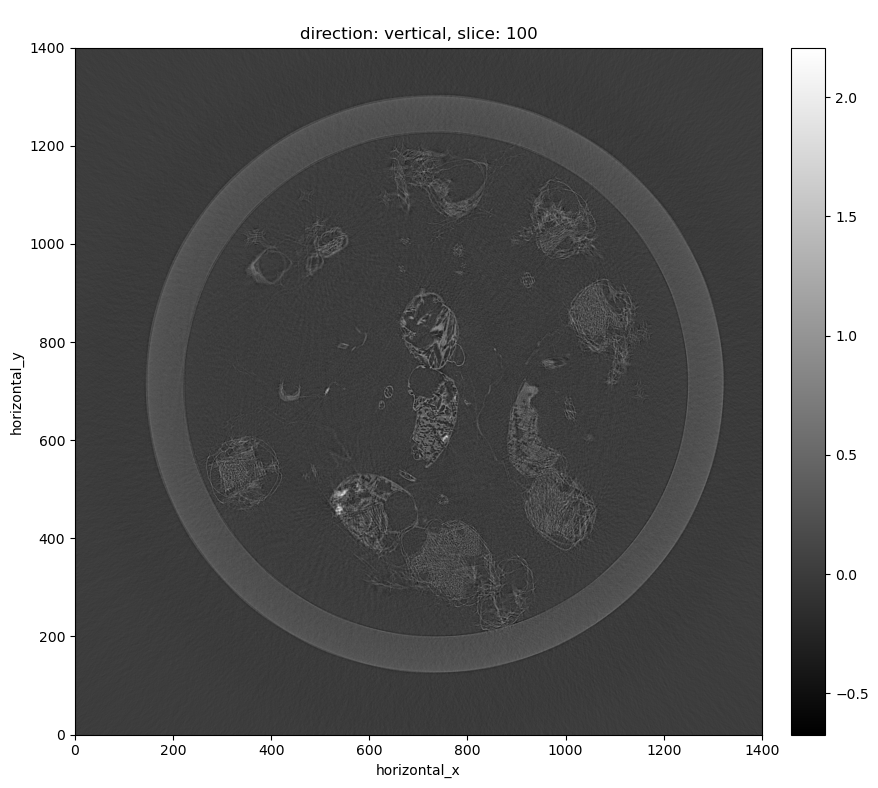

In [21]:
polaris.set_cor_offset_px(14.5)
recon = polaris.reconstruct()
show2D(recon)

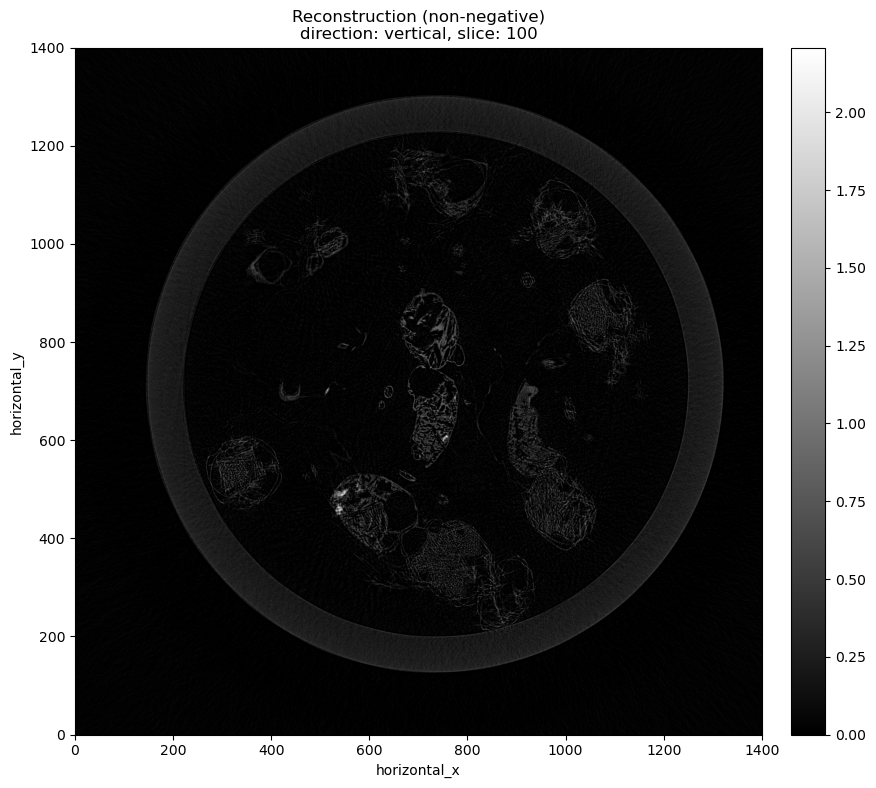

In [22]:
recon.array = np.clip(recon.array, 0, None)
show2D(recon, title='Reconstruction (non-negative)')

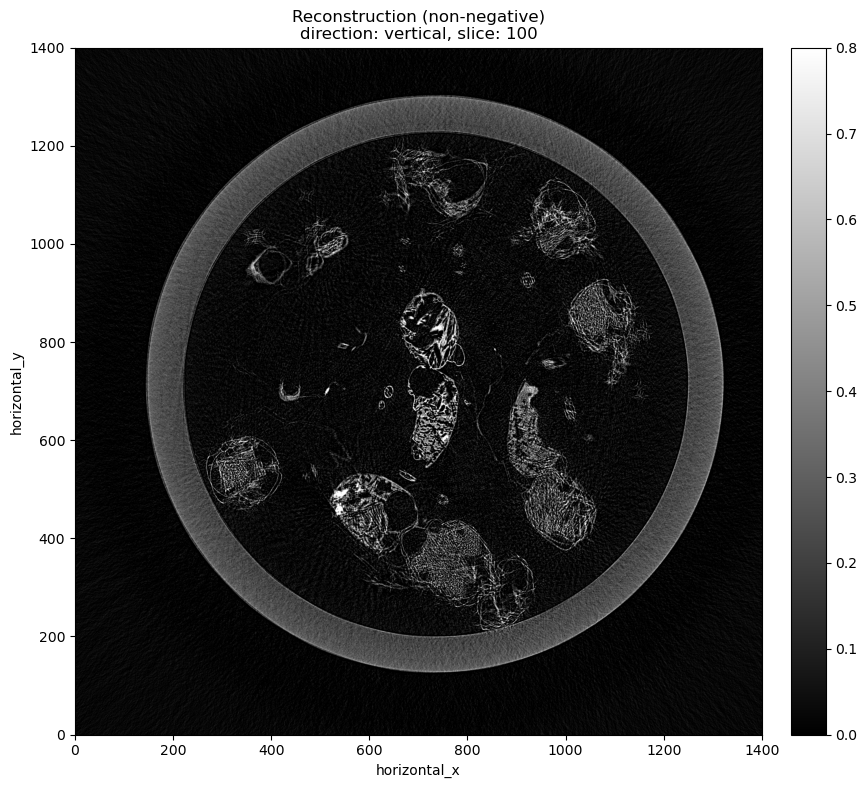

In [23]:
show2D(recon, title='Reconstruction (non-negative)',fix_range=(0, 0.8))

In [25]:
islicer(recon, minmax=(0, 0.8),size=(15,15))

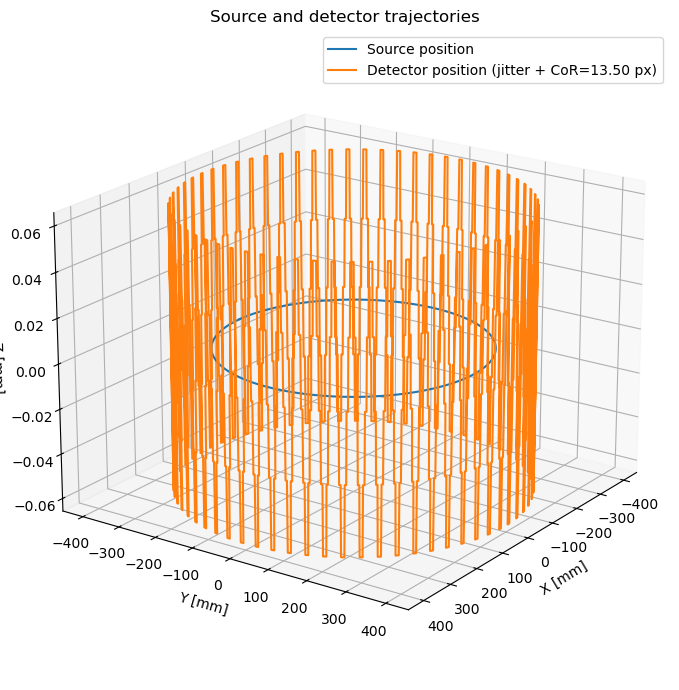

(<Figure size 700x700 with 1 Axes>,
 <Axes3D: title={'center': 'Source and detector trajectories'}, xlabel='X [mm]', ylabel='Y [mm]', zlabel='Z [mm]'>)

In [9]:
polaris.plot_source_detector_positions(include_cor_offset=True)

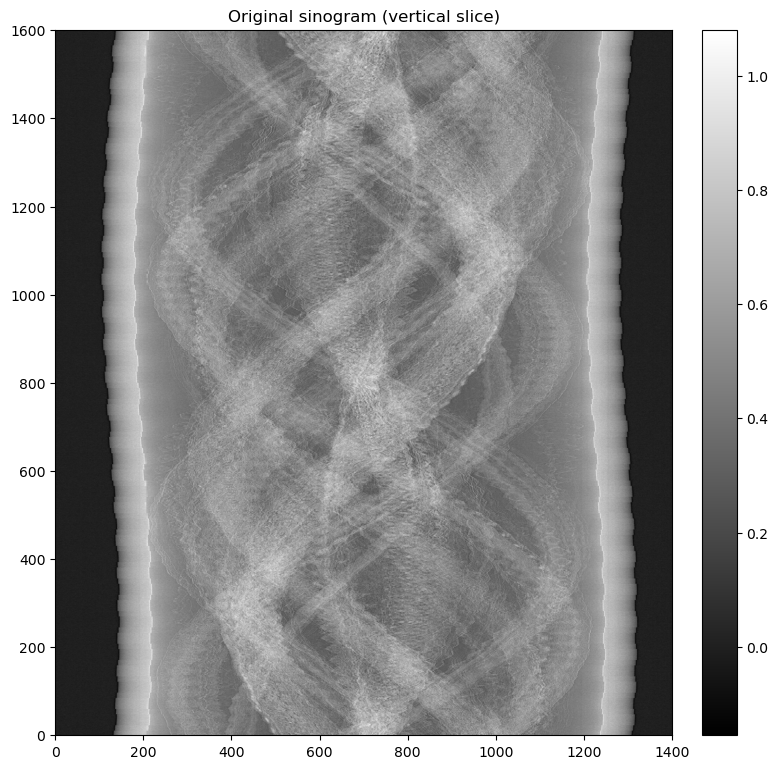

In [8]:
show2D(polaris.sinogram.array[:,100, :], title='Original sinogram (vertical slice)')

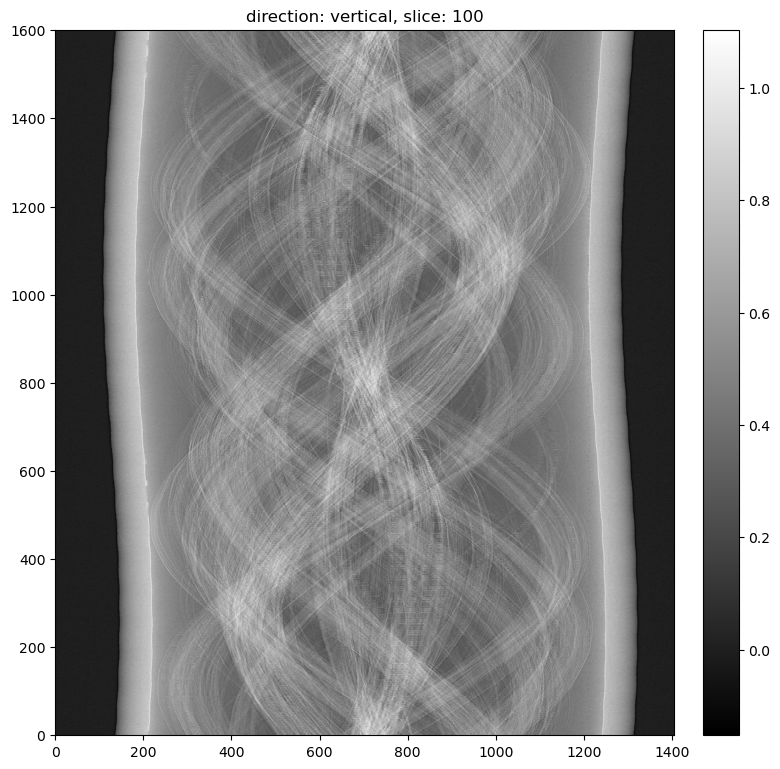

In [9]:
A_shifted = polaris.plot_jitter_corrected_sinogram(direction='vertical', slice_index=100, vertical_sign=-1.0, horizontal_sign=-1.0)

In [10]:
polaris._vertical_shift_px

array([ 2.25140535,  2.25140535, -0.        , ...,  4.50281509,
        4.50281509,  4.50281509])

In [11]:
polaris._horizontal_shift_px

array([-2.25140535, -2.25140535, -2.25140535, ...,  2.25140535,
        2.25140535,  2.25140535])

In [14]:
cloud_recon = qim3d.io.load("/dtu/3d-imaging-center/QIM/QIM_sandbox/rjupe/polaris_recon/mosquito_A.tif", progress_bar=True)

Loading:   0%|          | 0.00B/85.1GB  [00:00<?, ?B/s]

In [15]:
cloud_recon.shape

(4096, 4216, 4216)

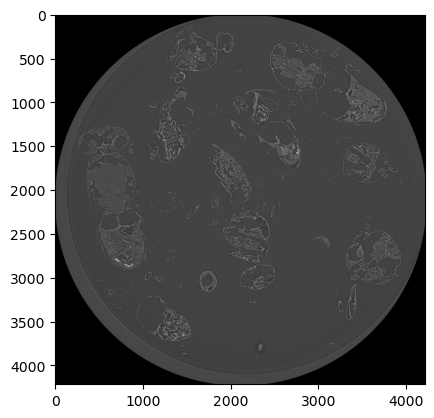

In [16]:
plt.imshow(cloud_recon[cloud_recon.shape[0] // 2], cmap='gray')

In [35]:
with Image.open("/dtu/3d-imaging-center/QIM/QIM_sandbox/rjupe/polaris_projections/ses-251127-110257-mosquitoa/02-tomo/Output/Binaries/tomo0010.tif") as img:
    tag_dict = {TAGS[key]: img.tag[key] for key in img.tag_v2}
    image_description = tag_dict.get('ImageDescription', [None])[0]
    if image_description is None:
        raise ValueError(f"Missing ImageDescription metadata in {file}")

    meta_dict = json.loads(image_description)

In [36]:
meta_dict

{'acquisition_date': '2025-11-27 11:03:50.281',
 'camera': {'averages': 1,
  'binning': {'horizontal': 2, 'vertical': 2},
  'exposure_s': 0.25,
  'gain': 2,
  'model': 'camera-photonicscience-gsense4040xl-221094',
  'roi_px': {'bot': 2047, 'left': 0, 'right': 2047, 'top': 0},
  'temperature_degC': 21.0},
 'filter': {'material': '', 'thickness_mm': 0.0},
 'pixel_shift_px': {'horizontal': 0.0, 'vertical': -5.14191},
 'source': {'e-beam_um': {'center': 0.0, 'height': 60.0, 'width': 20.0},
  'model': 'source-excillum-d2-exh-01184da',
  'power_W': 185.01,
  'power_measured_W': 186.36751,
  'voltage_V': 70000.0},
 'stage_position_mm': {'camera_beam': 708.001,
  'camera_transverse': -0.008,
  'object_align_bot': 0.419,
  'object_align_top': 0.802,
  'object_beam': 310.001,
  'object_rotation': 11.25004,
  'object_vertical': 198.9911}}

In [34]:
meta_dict

{'acquisition_date': '2025-11-27 11:03:42.154',
 'camera': {'averages': 1,
  'binning': {'horizontal': 2, 'vertical': 2},
  'exposure_s': 0.25,
  'gain': 2,
  'model': 'camera-photonicscience-gsense4040xl-221094',
  'roi_px': {'bot': 2047, 'left': 0, 'right': 2047, 'top': 0},
  'temperature_degC': 22.0},
 'filter': {'material': '', 'thickness_mm': 0.0},
 'pixel_shift_px': {'horizontal': -5.14191, 'vertical': -5.14191},
 'source': {'e-beam_um': {'center': 0.0, 'height': 60.0, 'width': 20.0},
  'model': 'source-excillum-d2-exh-01184da',
  'power_W': 185.01,
  'power_measured_W': 186.19539,
  'voltage_V': 70000.0},
 'stage_position_mm': {'camera_beam': 708.001,
  'camera_transverse': -0.008,
  'object_align_bot': 0.383,
  'object_align_top': 0.802,
  'object_beam': 310.001,
  'object_rotation': 0.0,
  'object_vertical': 198.9917}}